In [50]:
import pandas as pd
import numpy as np
import re
# import pyperclip
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("darkgrid")
sns.set_context("paper", font_scale=1.5, rc={"lines.linewidth": 2.5})
sns.set_palette("hls")
sns.set_color_codes("muted")
%matplotlib inline

In [103]:
repL4L="/Users/gilles/ownCloud/Recherche/Boye/HDR/Data/L4L/"
repIMM21=repL4L+"IMM21/"
typeResults="Complets"
typeControl="vlexique"

In [104]:
%store -r ordStemCells

In [105]:
%store -r pltCellColors

In [106]:
def colorerXTicks(gAX,fSize=12):
    xlabels=gAX.get_xticklabels()
    for xlabel in xlabels:
        xtext=xlabel.get_text()
        xlabel.set_backgroundcolor(pltCellColors[xtext])
        xlabel.set_family("monospace")

## Diff

In [107]:
serie=repIMM21+"IMM21-%s-X-Morphomes-Swim2-StemSpace-Diff-"+typeResults+"-"+typeControl+".pkl"
df0=pd.read_pickle(serie%"00").count()
df1=pd.read_pickle(serie%"01").count()
df2=pd.read_pickle(serie%"02").count()

In [108]:
cols=df0.index.tolist()
if typeResults=="Principaux":
    cols=[c for c in cols if not ("ai" in c or "is" in c)]
    ordStemCells=[c for c in ordStemCells if c in cols]


In [109]:
df=df1.reindex(ordStemCells).to_frame()
df.columns=["Full"]
df["Head"]=df0.reindex(ordStemCells).to_frame()
df["Tail"]=df2.reindex(ordStemCells).to_frame()
df=df.reset_index()
df.head()

,index,Full,Head,Tail
0,pi1S,15,15,20
1,pi2S,14,16,21
2,pi3S,14,16,22
3,pi1P,13,21,12
4,pi2P,14,24,14


In [110]:
dfMelted = pd.melt(df, id_vars=['index'],value_vars=['Full','Head','Tail'])
dfMelted.columns=["Cells",u"Generalisation Base","Number"]
dfMelted.head()

,Cells,Generalisation Base,Number
0,pi1S,Full,15
1,pi2S,Full,14
2,pi3S,Full,14
3,pi1P,Full,13
4,pi2P,Full,14


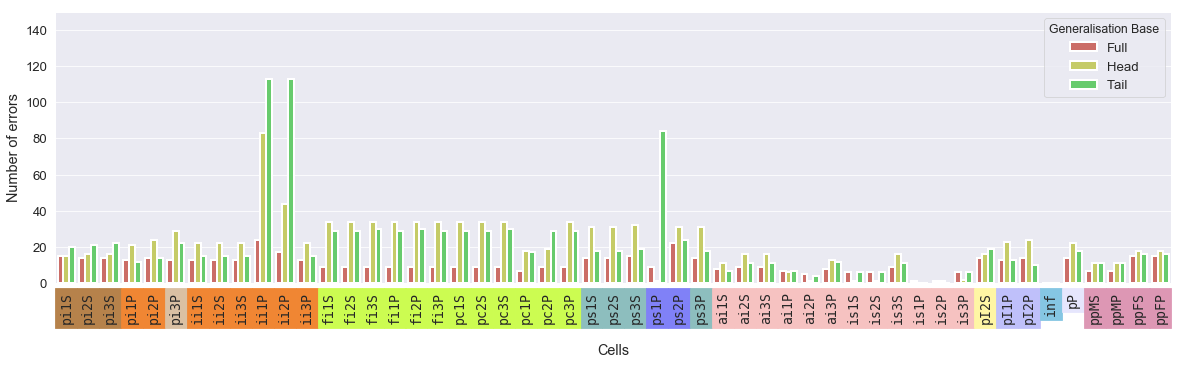

In [111]:
ax = sns.barplot(x="Cells", y="Number", hue=u"Generalisation Base", data=dfMelted,linewidth=2)#,palette=["red","green"])
ax.set_xlabel("\nCells")
ax.set_ylabel("Number of errors")
# ax.set_title("Distribution des erreurs en fonction des cases")
colorerXTicks(ax,fSize=10)
ax.tick_params(axis='x', labelrotation=90)
_=ax.set_ylim(0,150)
# _=ax.set_xlim("inf","is1P")
ax.figure.set_size_inches(20,5)
plt.savefig((serie%"012").replace(".pkl",".pdf"),dpi=300, bbox_inches = "tight")


## Missing

In [112]:
serie=repIMM21+"IMM21-%s-X-Morphomes-Swim2-StemSpace-Miss-"+typeResults+"-"+typeControl+".pkl"
df0=pd.read_pickle(serie%"00").count()
df1=pd.read_pickle(serie%"01").count()
df2=pd.read_pickle(serie%"02").count()

In [113]:
cols=df0.index.tolist()
if typeResults=="Principaux":
    cols=[c for c in cols if not ("ai" in c or "is" in c)]
    ordStemCells=[c for c in ordStemCells if c in cols]


In [114]:
df=df1.reindex(ordStemCells).to_frame()
df.columns=["Full"]
df["Head"]=df0.reindex(ordStemCells).to_frame()
df["Tail"]=df2.reindex(ordStemCells).to_frame()
df=df.reset_index()
df.head()

,index,Full,Head,Tail
0,pi1S,33,76,281
1,pi2S,29,39,281
2,pi3S,29,39,283
3,pi1P,4,4,27
4,pi2P,12,11,30


In [115]:
dfMelted = pd.melt(df, id_vars=['index'],value_vars=['Full','Head','Tail'])
dfMelted.columns=["Cells",u"Generalisation Base","Number"]
dfMelted.head()

,Cells,Generalisation Base,Number
0,pi1S,Full,33
1,pi2S,Full,29
2,pi3S,Full,29
3,pi1P,Full,4
4,pi2P,Full,12


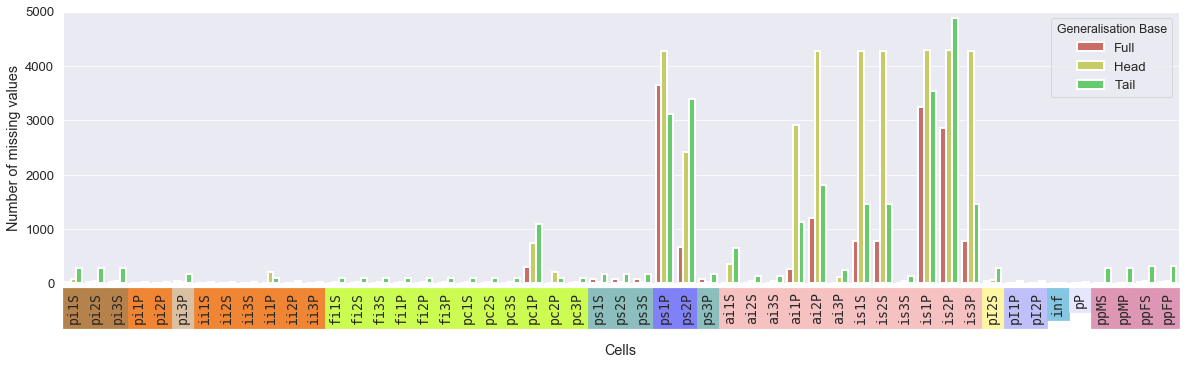

In [116]:
ax = sns.barplot(x="Cells", y="Number", hue=u"Generalisation Base", data=dfMelted,linewidth=2)#,palette=["red","green"])
ax.set_xlabel("\nCells")
ax.set_ylabel("Number of missing values")
# ax.set_title("Distribution des erreurs en fonction des cases")
colorerXTicks(ax,fSize=10)
ax.tick_params(axis='x', labelrotation=90)
_=ax.set_ylim(0,5000)
# _=ax.set_xlim("inf","is1P")
ax.figure.set_size_inches(20,5)
plt.savefig((serie%"012").replace(".pkl",".pdf"),dpi=300, bbox_inches = "tight")
